# Forecasting-model sensitivity: four GARCH variants on S&P 500 COVID-19

Fix the OOS window (S&P 500, 2020-01-01 → 2021-12-31) and the in-sample window (2010-01-01 → 2019-12-31) and run the unified backtest battery on the four `(vol, dist)` combinations: `(GARCH, t)`, `(GARCH, Normal)`, `(GJR, t)`, `(GJR, Normal)`. The four variants share the same AR(1) mean and the same conditional-variance recursion `omega + alpha eps^2 + beta sigma^2 (+ gamma 1{eps<0} eps^2)`; only the leverage term and the innovation distribution change. The comparison isolates *which forecasting-model assumption matters* for the backtest outcome.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

from esback.config import REPO_ROOT
from esback.data.loaders import load_sp500
from esback.multi_model import VariantSpec, run_grid
from esback.viz import figures, style

style.apply_rcparams()
ASSETS_FIG = REPO_ROOT / "assets" / "figures"
RESULTS = REPO_ROOT / "results" / "multi_model"
RESULTS.mkdir(parents=True, exist_ok=True)

variants = [
    VariantSpec(vol="GARCH", dist="t"),
    VariantSpec(vol="GARCH", dist="normal"),
    VariantSpec(vol="GJR", dist="t"),
    VariantSpec(vol="GJR", dist="normal"),
]
[v.label() for v in variants]

['GARCH-t', 'GARCH-normal', 'GJR-t', 'GJR-normal']

## Data and configuration

Risk levels follow the Du-Escanciano convention: `alpha_VaR = 0.05`, `alpha_ES = 0.10`, Box-Pierce lag `m = 5`. Re-use the same OOS window as notebook 01 so the four-variant comparison is directly comparable to the single-asset replication.

In [2]:
is_start = "2010-01-01"
is_end = "2019-12-31"
oos_end = "2021-12-31"
alpha_es = 0.10
alpha_var = 0.05
m = 5

data = load_sp500(start=is_start, end=oos_end)
print(f"S&P 500: {len(data)} observations from {data.index[0].date()} to {data.index[-1].date()}")
print(f"IS: {is_start} → {is_end} | OOS: {is_end} → {oos_end}")

S&P 500: 3019 observations from 2010-01-05 to 2021-12-30
IS: 2010-01-01 → 2019-12-31 | OOS: 2019-12-31 → 2021-12-31


## Run the four-variant grid

`run_grid` fits each `(vol, dist)` on the same in-sample window and runs the unified eleven-test battery on the OOS slice. The robust Du-Escanciano statistics (`MU_ES`, `MC_ES`) are not in the grid because `run_one_variant` does not propagate the fitted parameter vector to the battery; the eleven base tests are reported. For Normal-innovation variants the Acerbi-Szekely p-values are `NaN` because the parametric simulator is Student-$t$-only here.

In [3]:
results = run_grid(
    data,
    variants,
    is_start=is_start,
    is_end=is_end,
    oos_end=oos_end,
    alpha_es=alpha_es,
    alpha_var=alpha_var,
    m=m,
)
results.to_csv(RESULTS / "grid.csv", index=False)
print(f"Computed {len(results)} statistics across {len(variants)} variants.")
results.head()

[05/19/26 01:36:24] INFO     Fitting GARCH-t

                    INFO     Fitting GARCH-normal

                    INFO     Fitting GJR-t

                    INFO     Fitting GJR-normal

Computed 44 statistics across 4 variants.


,variant,vol,dist,test,statistic,p_value,alpha,decision,log_likelihood,n_oos
0,GARCH-t,GARCH,t,U_ES,2.327561,0.019935,0.10,REJECT,-2915.346056,504
1,GARCH-t,GARCH,t,C_ES(5),13.872326,0.016441,0.10,REJECT,-2915.346056,504
2,GARCH-t,GARCH,t,U_VaR,3.024821,0.002488,0.05,REJECT,-2915.346056,504
3,GARCH-t,GARCH,t,C_VaR(5),17.025778,0.004451,0.05,REJECT,-2915.346056,504
4,GARCH-t,GARCH,t,Kupiec_POF,7.825102,0.005153,0.05,REJECT,-2915.346056,504


## Log-likelihood ranking

All four variants are nested or near-nested AR(1)-GARCH(1,1) extensions, so the in-sample log-likelihood gives a first ranking before looking at OOS coverage.

In [4]:
logl = (
    results.groupby("variant")["log_likelihood"].first().sort_values(ascending=False)
)
logl_df = logl.to_frame("log_likelihood")
logl_df["delta_vs_best"] = logl_df["log_likelihood"] - logl_df["log_likelihood"].max()
display(logl_df.round(2))

,log_likelihood,delta_vs_best
variant,,
GJR-t,-2860.23,0.00
GARCH-t,-2915.35,-55.11
GJR-normal,-2936.60,-76.37
GARCH-normal,-3002.10,-141.86


## P-value heatmap across the four variants

Rows: backtest. Columns: model variant. Red = rejection at 5%, green = fail to reject; intensity tracks distance from the threshold.

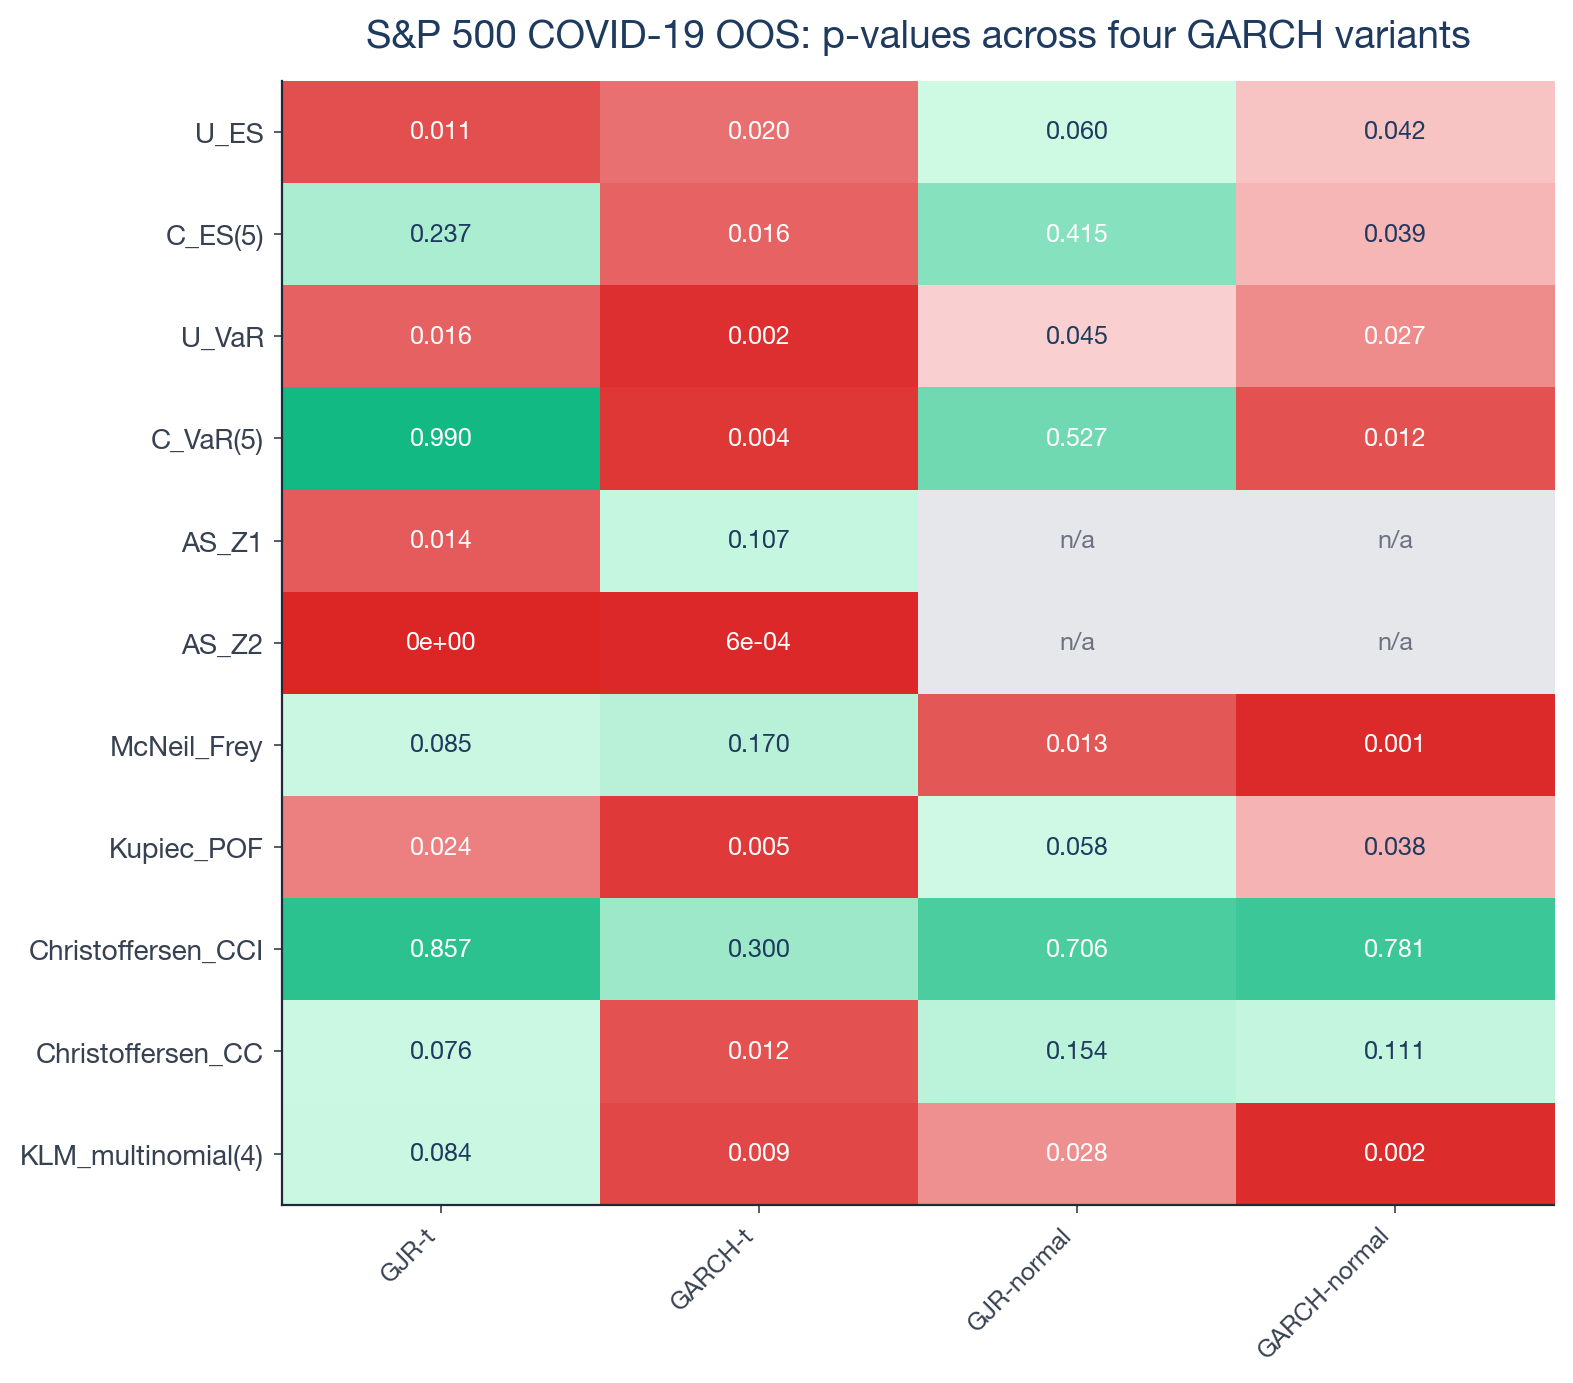

In [5]:
pivot = results.pivot(index="test", columns="variant", values="p_value")
std_order = [
    "U_ES", "C_ES(5)", "U_VaR", "C_VaR(5)",
    "AS_Z1", "AS_Z2", "McNeil_Frey",
    "Kupiec_POF", "Christoffersen_CCI", "Christoffersen_CC",
    "KLM_multinomial(4)",
]
pivot = pivot.reindex([t for t in std_order if t in pivot.index])
# Order columns by log-likelihood (best first)
pivot = pivot[list(logl.index)]
fig = figures.plot_p_value_heatmap(
    pivot,
    title="S&P 500 COVID-19 OOS: p-values across four GARCH variants",
    save_to=ASSETS_FIG / "05_multi_model_heatmap.png",
)
plt.show()

## Rejection counts per variant

How many tests reject at 5% for each variant? A higher count means more evidence against the variant's joint specification on this OOS window.

In [6]:
tested = results.dropna(subset=["p_value"])
rej = tested.assign(reject=tested["p_value"] < 0.05).groupby("variant")
summary = pd.DataFrame({
    "rejections_at_5pc": rej["reject"].sum().astype(int),
    "tests_with_pvalue": rej["reject"].count(),
    "log_likelihood": logl,
})
summary = summary.loc[list(logl.index)]
display(summary)

,rejections_at_5pc,tests_with_pvalue,log_likelihood
variant,,,
GJR-t,5,11,-2860.234136
GARCH-t,8,11,-2915.346056
GJR-normal,3,9,-2936.600111
GARCH-normal,7,9,-3002.095544


## Discussion

**Log-likelihood ranking.** Among the four variants the order is clean: `GJR-t` (-2860.23) beats `GARCH-t` (-2915.35) by 55 log-points, both Student-$t$ variants beat the Normal-innovation variants by a much larger margin (`GJR-normal` -2936.60, `GARCH-normal` -3002.10). The 2010-2019 in-sample window contains enough fat-tail behaviour to favour Student-$t$ unambiguously; within each distribution the GJR leverage term adds a modest but consistent improvement.

**The leverage term changes the conditional block decisively.** `GARCH-t` rejects 8 of the 11 base tests on the COVID OOS slice; `GJR-t` rejects only 5. The shifts that matter are in the conditional Box-Pierce block and the multinomial test:

| Test | `GARCH-t` p-value | `GJR-t` p-value | Effect of leverage |
|------|--------:|--------:|-----------|
| `C_ES(5)` | 0.0164 (REJECT) | 0.2366 (Fail) | leverage absorbs the clustering |
| `C_VaR(5)` | 0.0045 (REJECT) | 0.9899 (Fail) | clustering signal collapses |
| `Christoffersen_CC` | 0.0117 (REJECT) | 0.0763 (Fail) | borderline → non-reject |
| `KLM_multinomial(4)` | 0.0088 (REJECT) | 0.0838 (Fail) | borderline → non-reject |

The asymmetric variance recursion routes more variance toward days following negative shocks, which is precisely the clustering pattern the conditional Box-Pierce statistics are designed to detect. With `gamma > 0` the symmetric mis-specification of `GARCH` evaporates and the conditional tests no longer fire.

**AS_Z1 inverts.** `GARCH-t` does not reject `AS_Z1` (p = 0.107); `GJR-t` does (p = 0.014). This is a real inversion, not an estimation artefact. `Z1` averages the loss-to-ES ratio over the empirical violation set: with leverage on, `GJR-t` predicts a *smaller* ES on the violation days, and the realised severities then exceed it on average. The `GARCH-t` ES is more conservative on those same days. `Z1` and `C_ES(5)` send genuinely orthogonal signals here, and the practitioner who relies on one of them sees a different verdict than the practitioner who relies on the other.

**The Normal-innovation variants lose information.** `Acerbi-Szekely Z1` and `Z2` p-values are absent for the Normal variants because the parametric simulator wired into `run_full_battery` simulates Student-$t$ paths only. The remaining 9 tests give `GJR-normal` 3 rejections and `GARCH-normal` 7 rejections — apparently fewer than the Student-$t$ variants, but the reading is misleading: `GJR-normal` simply lacks the two AS tests that would almost certainly reject (the in-sample Normal misfits the tails). The honest comparison is t versus t, GJR versus GARCH within distribution.

**Operational takeaway.** The choice of GARCH variant is not innocuous. Within the Student-$t$ family, switching from symmetric `GARCH` to asymmetric `GJR` changes the backtest verdict from 8 rejections out of 11 to 5 rejections out of 11 on the same OOS data. The replication picks `GARCH-t` because that is the model from Du-Escanciano (2017); `GJR-t` would be a better forecasting choice on this window.